In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
X = np.array([
650, 785, 1200, 1375, 1500, 1650, 1800, 1950,
2100, 2250, 2400, 2550, 2700, 2850, 3000, 3200,
3400, 3600, 3850, 4100
], dtype=float)

In [3]:
y = np.array([
3200, 3650, 5100, 5700, 6050, 6700, 7150, 7800,
8250, 8900, 9400, 9950, 10400, 10900, 11500, 12300,
13050, 13700, 14600, 15400
], dtype=float)

In [4]:
df = pd.DataFrame({'Size': X, 'Price': y})

In [5]:
df.head()

,Size,Price
0,650.0,3200.0
1,785.0,3650.0
2,1200.0,5100.0
3,1375.0,5700.0
4,1500.0,6050.0


In [13]:
X = df[["Size"]]
y = df["Price"].values

In [6]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [7]:
scaler = StandardScaler()


In [14]:
X_std = scaler.fit_transform(df[["Size"]]).flatten()
X_std

array([-1.74428318, -1.60539894, -1.1784585 , -0.99842337, -0.86982685,
       -0.71551103, -0.56119521, -0.40687938, -0.25256356, -0.09824774,
        0.05606808,  0.2103839 ,  0.36469973,  0.51901555,  0.67333137,
        0.8790858 ,  1.08484023,  1.29059466,  1.5477877 ,  1.80498073])

In [15]:
def gradient_descent(X, y, lr, epochs):
    n = len(X)
    w = 0
    b = 0
    losses = []

    for epoch in range(epochs):
        y_pred = w * X + b
        error = y_pred - y

        loss = np.mean(error ** 2)
        losses.append(loss)

        # gradients
        dw = (2/n) * np.dot(error, X)
        db = (2/n) * np.sum(error)

        # update
        w -= lr * dw
        b -= lr * db

    return w, b, losses

In [16]:
epochs = 1000
learning_rates = [0.001, 0.01, 0.5]

results = {}

for lr in learning_rates:
    w, b, losses = gradient_descent(X_std, y, lr, epochs)
    y_pred = w * X_std + b
    error = rmse(y, y_pred)

    results[lr] = (w, b, error, losses)

    print(f"Learning Rate: {lr}")
    print(f"Final Weight (w): {w:.4f}, Bias (b): {b:.4f}")
    print(f"RMSE: {error:.4f}\n")


Learning Rate: 0.001
Final Weight (w): 3006.3466, Bias (b): 7944.4324
RMSE: 1327.6699

Learning Rate: 0.01
Final Weight (w): 3475.8044, Bias (b): 9185.0000
RMSE: 57.5197

Learning Rate: 0.5
Final Weight (w): 3475.8044, Bias (b): 9185.0000
RMSE: 57.5197



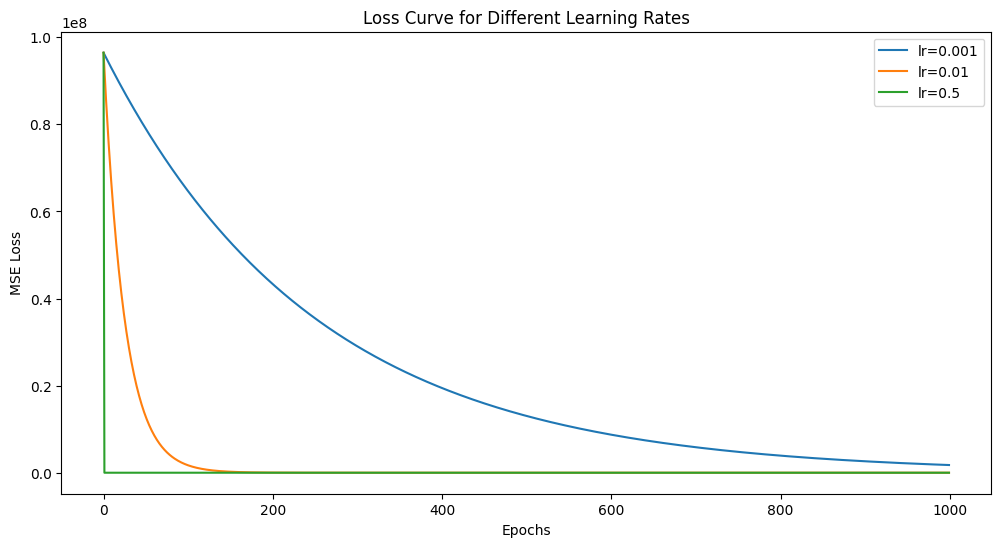

In [22]:
plt.figure(figsize=(12,6))
for lr in learning_rates:
    plt.plot(results[lr][3], label=f"lr={lr}")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss Curve for Different Learning Rates")
plt.legend()
plt.show()
